In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import PureWindowsPath
from tqdm.notebook import tqdm 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from PIL import Image
import skimage.io

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc

import skimage, torch, torchvision
import torchxrayvision as xrv
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from transformers import AutoModel, AutoImageProcessor

current_path = os.getcwd()

os.chdir('..')
print(f"current path: {current_path}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

current path: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/preprocess


In [2]:
processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
model = AutoModel.from_pretrained("microsoft/rad-dino")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [3]:
print(processor)

BitImageProcessor {
  "crop_size": {
    "height": 518,
    "width": 518
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5307,
    0.5307,
    0.5307
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.2583,
    0.2583,
    0.2583
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 518
  }
}



In [4]:
# label
label_csv = pd.read_csv('mimic-cxr-2.0.0-chexpert.csv.gz', compression='gzip')

# # Whole CXR data
# all_image_paths = []
# root_dir = '/home/DAHS1/mimic-cxr-jpg-2.0.0'
# for dirpath, _, filenames in os.walk(root_dir):
#     for filename in filenames:
#         if filename.lower().endswith('.jpg'):
#             all_image_paths.append(os.path.join(dirpath, filename))
# print(f"총 {len(all_image_paths)}개의 이미지 파일")

# ====================================================================================

# # frontal-view data
# root_dir = '/home/DAHS1/mimic-cxr-jpg-2.0.0'

# vp_extract_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/final_cxr_df_20260504.ftr")
# filtered = vp_extract_df[vp_extract_df['ViewPosition'].isin(['AP', 'PA'])]

# image_paths = [os.path.join(root_dir, p) for p in filtered['image_path']]
# filtered['full_path'] = filtered['image_path'].apply(lambda p: os.path.join(root_dir, p))

# frontal_image_paths = filtered['full_path'].tolist()
# print(f"총 {len(frontal_image_paths)}개의 Frontal View 이미지 파일")

# ====================================================================================

# # ICU-CXR data
# icu_cxr_paths = []
# root_dir = 'icu_cxr/mimic-cxr-jpg'
# for dirpath, _, filenames in os.walk(root_dir):
#     for filename in filenames:
#         if filename.lower().endswith('.jpg'):
#             icu_cxr_paths.append(os.path.join(dirpath, filename))
# print(f"총 {len(icu_cxr_paths)}개의 이미지 파일")


root_dir = '/home/DAHS1/mimic-cxr-jpg-2.0.0'

existing_df = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/final_cxr_df_in_icu_20260511.ftr')

cohort_image_paths = existing_df['image_path'].dropna().unique().tolist()
all_image_paths = [os.path.join(root_dir, path) for path in cohort_image_paths]
print(f"총 {len(all_image_paths)}개의 이미지 파일")

총 53228개의 이미지 파일


### Rad-Dino

In [5]:
raddino_save_root = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/raddino_cxr_embeddings'
os.makedirs(raddino_save_root, exist_ok=True)

In [6]:
my_pathologies = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Lung Opacity']
num_classes = len(my_pathologies)
print(f"학습할 타겟 클래스 수: {num_classes}")

학습할 타겟 클래스 수: 7


In [7]:
class RAD_DINODataset(Dataset):
    def __init__(self, image_paths, label_df, pathologies, processor):
        self.image_paths = image_paths
        self.label_df = label_df
        self.pathologies = pathologies
        self.processor = processor
        self.label_dict = label_df.set_index('study_id').to_dict('index')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        try:
            study_id_str = img_path.split("/")[-2]
            study_id = int(study_id_str[1:]) if study_id_str.startswith('s') else int(study_id_str)
            subject_data = self.label_dict.get(study_id)

            label_row = []
            if subject_data is not None:
                for p in self.pathologies:
                    val = subject_data.get(p, np.nan)

                    if pd.isna(val):
                        label_row.append(-9) # 과거에는 NaN을 -9로 처리하였음.
                    elif val == 1.0:
                        label_row.append(1)
                    else:
                        label_row.append(0) # U-zeros
            else:
                label_row = [-9] * len(self.pathologies)

        except Exception as e:
            label_row = [-9] * len(self.pathologies)

        return pixel_values, torch.tensor(label_row, dtype=torch.float32), img_path

all_ds = RAD_DINODataset(all_image_paths, label_csv, my_pathologies, processor)
all_loader = DataLoader(all_ds, batch_size=256, shuffle=False, num_workers=8)

backbone = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
backbone.eval()
for param in backbone.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [8]:
backbone

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,),

In [9]:
# class LinearClassifier(nn.Module):
#     def __init__(self, input_dim=768, num_classes=7):
#         super(LinearClassifier, self).__init__()
#         self.linear = nn.Linear(input_dim, num_classes)
        
#     def forward(self, x):
#         return self.linear(x)

In [10]:
save_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/raddino_cxr_embeddings(2)"

In [11]:
existing_files = set(os.listdir(save_dir))

filtered_image_paths = []

for img_path in all_image_paths:
    path_parts = img_path.split('/')
    file_id = "_".join(path_parts[-4:]).replace('.jpg', '.pt')
    
    # 디렉토리에 동일한 파일명이 없을 때만 추출 대상에 추가
    if file_id not in existing_files:
        filtered_image_paths.append(img_path)

print(f"📊 총 코호트 이미지: {len(all_image_paths)}개")
print(f"✅ 이미 완료되어 건너뛸 이미지: {len(all_image_paths) - len(filtered_image_paths)}개")
print(f"🚀 실제로 새로 추출할 이미지: {len(filtered_image_paths)}개")

📊 총 코호트 이미지: 53228개
✅ 이미 완료되어 건너뛸 이미지: 0개
🚀 실제로 새로 추출할 이미지: 53228개


In [12]:
all_ds = RAD_DINODataset(filtered_image_paths, label_csv, my_pathologies, processor)
all_loader = DataLoader(all_ds, batch_size=256, shuffle=False, num_workers=8)

In [13]:
# def spatial_pool_patches(patch_tokens, h_patches, w_patches):
#     """
#     patch_tokens: (N, 768), N = h_patches × w_patches
#     반환: (5, 768) — center, top-left, top-right, bottom-left, bottom-right
#     """
#     # (N, 768) → (h, w, 768)
#     patches_2d = patch_tokens.reshape(h_patches, w_patches, -1)
    
#     h_mid = h_patches // 2
#     w_mid = w_patches // 2

#     center     = patches_2d[h_mid-1:h_mid+1, w_mid-1:w_mid+1].reshape(-1, 768).mean(0)
#     top_left   = patches_2d[:h_mid, :w_mid].reshape(-1, 768).mean(0)
#     top_right  = patches_2d[:h_mid, w_mid:].reshape(-1, 768).mean(0)
#     bot_left   = patches_2d[h_mid:, :w_mid].reshape(-1, 768).mean(0)
#     bot_right  = patches_2d[h_mid:, w_mid:].reshape(-1, 768).mean(0)

#     return torch.stack([center, top_left, top_right, bot_left, bot_right], dim=0)

In [ ]:
def extract_cache_raddino(loader, backbone, device, save_dir):
    backbone.eval()

    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for images, labels, paths in tqdm(loader):
            images = images.to(device)
            outputs = backbone(images)

            hidden = outputs.last_hidden_state          # (B, 1+N, 768)
            cls_tokens   = hidden[:, 0, :]              # (B, 768)
            patch_tokens = hidden[:, 1:, :]             # (B, 196, 768)

            # 입력 224px 기준 14×14 grid
            h_patches = w_patches = images.shape[-1] // 14

            for i in range(len(paths)):
                img_path = paths[i]
                path_parts = img_path.split('/')
                file_id = "_".join(path_parts[-4:]).replace('.jpg', '.pt')
                save_path = os.path.join(save_dir, file_id)

                if os.path.exists(save_path):
                    continue

                load = {
                    "global_emb": cls_tokens[i],   # (768,) 
                    "patch_emb":   patch_tokens[i].half(), # (256, 768) fp16
                    "patch_grid":  (h_patches, w_patches),  # Fourier PE 복원용
                    "label":       labels[i],
                    "path":        img_path
                }

                torch.save(load, save_path)

extract_cache_raddino(all_loader, backbone, device, save_dir)

  0%|          | 0/208 [00:00<?, ?it/s]

RuntimeError: [enforce fail at inline_container.cc:672] . unexpected pos 1408 vs 1238

In [ ]:
sample = torch.load(os.path.join(save_dir, os.listdir(save_dir)[0]))
print(sample["global_emb"].shape)   # torch.Size([768])
print(sample["patch_emb"].shape)    # torch.Size([256, 768])
print(sample["patch_grid"])         # (16, 16)
print(sample["label"])

In [12]:
def extract_cache_raddino(loader, backbone, device, save_dir):
    backbone.eval()

    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for images, labels, paths in tqdm(loader, desc="Extracting Rad-DINO Features"):
            images = images.to(device)
            outputs = backbone(images)

            cls_tokens = outputs.last_hidden_state[:, 0, :].half().cpu()

            for i in range(len(paths)):
                img_path = paths[i]
                path_parts = img_path.split('/')
                file_id = "_".join(path_parts[-4:]).replace('.jpg', '.pt')
                save_path = os.path.join(save_dir, file_id)

                if os.path.exists(save_path):
                    continue

                load = {
                    "global_emb": cls_tokens[i],
                    "label": labels[i],
                    "path": img_path
                }

                torch.save(load, save_path)

extract_cache_raddino(all_loader, backbone, device, raddino_save_root)

Extracting Rad-DINO Features:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
loaded_data = torch.load("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/raddino_cxr_embeddings/p10_p10001884_s50712381_7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.pt")

emb = loaded_data['global_emb']
label = loaded_data['label']
img_path = loaded_data['path']

print(type(loaded_data))
print(emb.dtype)
print(label)

<class 'dict'>
torch.float16
tensor([-9.,  1., -9.,  1.,  1., -9., -9.])


---

In [10]:
unique, counts = np.unique(all_labels_tensor.numpy(), return_counts=True)
print(dict(zip(unique, counts)))

{np.float32(-9.0): np.int64(236806), np.float32(0.0): np.int64(39974), np.float32(1.0): np.int64(95438)}


In [ ]:
# torch.save({'features': all_features, 'labels': all_labels_tensor}, 'dino_all_features.pt')

In [12]:
torch.save({'features': all_features, 'labels': all_labels_tensor}, 'total_frontal_view_dino_all_features.pt')

In [12]:
data = torch.load('total_frontal_view_dino_all_features.pt')
all_features = data['features']
all_labels_tensor = data['labels']

In [13]:
k_folds = 5

gkf = GroupKFold(n_splits=k_folds)

subjects_list = []

for img_path in tqdm(frontal_image_paths, total=len(frontal_image_paths), desc="Extract subject_id for split"):
    try:
        study_id_str = img_path.split("/")[-2]
        study_id = int(study_id_str[1:]) if study_id_str.startswith('s') else int(study_id_str)
        subject_row = label_csv[label_csv['study_id'] == study_id]

        if not subject_row.empty:
            subjects_list.append(subject_row.iloc[0]['subject_id'])
        else:
            subjects_list.append(f"unknown_{study_id}")
    except Exception as e:
        subjects_list.append(f"error_{len(subjects_list)}")

subjects = np.array(subjects_list)

print(f"특징(Features) 개수: {len(all_features)} | 환자 ID(Subjects) 개수: {len(subjects)}")
assert len(all_features) == len(subjects), "특징과 환자 ID의 개수가 다릅니다!"

fold_metrics = {'AUC': [], 'PRC': []}
label_metrics = {p: {'AUC': [], 'PRC': []} for p in my_pathologies}

epochs = 200
patience = 10
feature_batch_size = 256
patience_counter = 0

scaler = torch.amp.GradScaler("cuda")

for fold, (train_idx, val_idx) in enumerate(gkf.split(all_features, groups=subjects)):
    print("\n" + "="*50)
    print(f"FOLD {fold+1}/{k_folds} 시작")
    print("="*50)

    train_feats, val_feats = all_features[train_idx], all_features[val_idx]
    train_labs, val_labs = all_labels_tensor[train_idx], all_labels_tensor[val_idx]

    train_feature_loader = DataLoader(TensorDataset(train_feats, train_labs), batch_size=feature_batch_size, shuffle=True)
    val_feature_loader = DataLoader(TensorDataset(val_feats, val_labs), batch_size=feature_batch_size, shuffle=False)

    classifier = LinearClassifier(input_dim=768, num_classes=len(my_pathologies)).to(device)
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=5e-5)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss(reduction='none')

    best_val_loss = float('inf')
    best_auc = 0.0
    best_prc = 0.0
    patience_counter = 0

    best_epoch_label_scores = {p: {'AUC': None, 'PRC': None} for p in my_pathologies}

    epoch_pbar = tqdm(range(epochs), desc=f"Fold {fold+1} Training")
    for epoch in epoch_pbar:
        classifier.train()

        for features, labels in train_feature_loader:
            features, labels = features.to(device), labels.to(device)

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = classifier(features)
                mask = (labels != -9).float()
                safe_labels = labels.clone()
                safe_labels[labels == -9] = 0.0

                loss_matrix = criterion(logits, safe_labels)
                loss = (loss_matrix * mask).sum() / mask.sum().clamp(min=1e-8)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        classifier.eval()
        val_loss = 0.0
        val_preds_list, val_labels_list = [], []

        with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
            for features, labels in val_feature_loader:
                features, labels = features.to(device), labels.to(device)
                logits = classifier(features)
                mask = (labels != -9).float()
                safe_labels = labels.clone()
                safe_labels[labels == -9] = 0.0

                loss_matrix = criterion(logits, safe_labels)
                batch_val_loss = (loss_matrix * mask).sum() / mask.sum().clamp(min=1e-8)
                val_loss += batch_val_loss.item()

                probs = torch.sigmoid(logits)
                val_preds_list.append(probs.cpu().numpy())
                val_labels_list.append(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_feature_loader)
        val_labels_arr = np.concatenate(val_labels_list)
        val_preds_arr = np.concatenate(val_preds_list)

        fold_auc_scores, fold_prc_scores = [], []
        current_epoch_scores = {}

        for i, pathology in enumerate(my_pathologies):
            valid_mask = val_labels_arr[:, i] != -9
            y_true = val_labels_arr[valid_mask, i]
            y_score = val_preds_arr[valid_mask, i]

            if len(y_true) > 0 and len(np.unique(y_true)) > 1:
                auc = roc_auc_score(y_true, y_score)
                prc = average_precision_score(y_true, y_score)
                fold_auc_scores.append(auc)
                fold_prc_scores.append(prc)
                current_epoch_scores[pathology] = {'AUC': auc, 'PRC': prc}

            else:
                current_epoch_scores[pathology] = {'AUC': None, 'PRC': None}

        mean_auc = np.mean(fold_auc_scores) if fold_auc_scores else 0.0
        mean_prc = np.mean(fold_prc_scores) if fold_prc_scores else 0.0

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_auc = mean_auc
            best_prc = mean_prc
            best_epoch_label_scores = current_epoch_scores

            patience_counter = 0
            torch.save(classifier.state_dict(), f"best_dino_linear_head_fold_{fold+1}.pth")
            epoch_pbar.set_postfix({"Best Val Loss": f"{best_val_loss:.4f}"})

        else:
            patience_counter += 1
            if patience_counter >= patience:
                epoch_pbar.write(f"\n[*] Early Stopping Triggered (Epoch {epoch+1})")
                break

        scheduler.step()

    print(f"\n✅ Fold {fold+1} | Best Val Loss: {best_val_loss:.4f} | Mean AUROC: {best_auc:.4f} | Mean AUPRC: {best_prc:.4f}")
    print("-" * 50)

    del classifier, optimizer, scheduler
    torch.cuda.empty_cache()

    for pathology in my_pathologies:
        scores = best_epoch_label_scores[pathology]
        if scores['AUC'] is not None:
            print(f" {pathology:22s} | AUROC: {scores['AUC']:.4f} | AUPRC: {scores['PRC']:.4f}")
            label_metrics[pathology]['AUC'].append(scores['AUC'])
            label_metrics[pathology]['PRC'].append(scores['PRC'])

    fold_metrics['AUC'].append(best_auc)
    fold_metrics['PRC'].append(best_prc)

print("\n" + "="*50)
print("<5-Fold Cross-Validation Summary>")

for pathology in my_pathologies:
    auc_list = label_metrics[pathology]['AUC']
    prc_list = label_metrics[pathology]['PRC']

    if len(auc_list) > 0:
        print(f" {pathology:22s} | AUROC: {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f} | AUPRC: {np.mean(prc_list):.4f} ± {np.std(prc_list):.4f}")

print("="*50)
print(f" {'Overall Target Mean':22s} | AUROC: {np.mean(fold_metrics['AUC']):.4f} ± {np.std(fold_metrics['AUC']):.4f} | AUPRC: {np.mean(fold_metrics['PRC']):.4f} ± {np.std(fold_metrics['PRC']):.4f}")
print("="*50)

Extract subject_id for split:   0%|          | 0/243324 [00:00<?, ?it/s]

특징(Features) 개수: 243324 | 환자 ID(Subjects) 개수: 243324

FOLD 1/5 시작


Fold 1 Training:   0%|          | 0/200 [00:00<?, ?it/s]


[*] Early Stopping Triggered (Epoch 65)

✅ Fold 1 | Best Val Loss: 0.4621 | Mean AUROC: 0.7679 | Mean AUPRC: 0.7988
--------------------------------------------------
 Atelectasis            | AUROC: 0.6563 | AUPRC: 0.8762
 Cardiomegaly           | AUROC: 0.8178 | AUPRC: 0.8872
 Consolidation          | AUROC: 0.8329 | AUPRC: 0.7865
 Edema                  | AUROC: 0.8217 | AUPRC: 0.7426
 Pleural Effusion       | AUROC: 0.8815 | AUPRC: 0.9166
 Pneumonia              | AUROC: 0.6768 | AUPRC: 0.4432
 Lung Opacity           | AUROC: 0.6883 | AUPRC: 0.9394

FOLD 2/5 시작


Fold 2 Training:   0%|          | 0/200 [00:00<?, ?it/s]

...


[*] Early Stopping Triggered (Epoch 75)

✅ Fold 3 | Best Val Loss: 0.4554 | Mean AUROC: 0.7728 | Mean AUPRC: 0.8017
--------------------------------------------------
 Atelectasis            | AUROC: 0.6521 | AUPRC: 0.8730
 Cardiomegaly           | AUROC: 0.8173 | AUPRC: 0.8889
 Consolidation          | AUROC: 0.8517 | AUPRC: 0.8145
 Edema                  | AUROC: 0.8237 | AUPRC: 0.7401
 Pleural Effusion       | AUROC: 0.8879 | AUPRC: 0.9240
 Pneumonia              | AUROC: 0.6697 | AUPRC: 0.4270
 Lung Opacity           | AUROC: 0.7073 | AUPRC: 0.9447

FOLD 4/5 시작


Fold 4 Training:   0%|          | 0/200 [00:00<?, ?it/s]


[*] Early Stopping Triggered (Epoch 94)

✅ Fold 4 | Best Val Loss: 0.4605 | Mean AUROC: 0.7697 | Mean AUPRC: 0.8041
--------------------------------------------------
 Atelectasis            | AUROC: 0.6300 | AUPRC: 0.8574
 Cardiomegaly           | AUROC: 0.8152 | AUPRC: 0.8833
 Consolidation          | AUROC: 0.8506 | AUPRC: 0.8244
 Edema                  | AUROC: 0.8256 | AUPRC: 0.7493
 Pleural Effusion       | AUROC: 0.8864 | AUPRC: 0.9210
 Pneumonia              | AUROC: 0.6833 | AUPRC: 0.4540
 Lung Opacity           | AUROC: 0.6968 | AUPRC: 0.9393

FOLD 5/5 시작


Fold 5 Training:   0%|          | 0/200 [00:00<?, ?it/s]


[*] Early Stopping Triggered (Epoch 66)

✅ Fold 5 | Best Val Loss: 0.4612 | Mean AUROC: 0.7693 | Mean AUPRC: 0.8019
--------------------------------------------------
 Atelectasis            | AUROC: 0.6459 | AUPRC: 0.8670
 Cardiomegaly           | AUROC: 0.8248 | AUPRC: 0.8940
 Consolidation          | AUROC: 0.8340 | AUPRC: 0.8016
 Edema                  | AUROC: 0.8240 | AUPRC: 0.7439
 Pleural Effusion       | AUROC: 0.8873 | AUPRC: 0.9175
 Pneumonia              | AUROC: 0.6769 | AUPRC: 0.4517
 Lung Opacity           | AUROC: 0.6921 | AUPRC: 0.9375

<5-Fold Cross-Validation Summary>
 Atelectasis            | AUROC: 0.6463 ± 0.0089 | AUPRC: 0.8689 ± 0.0065
 Cardiomegaly           | AUROC: 0.8166 ± 0.0054 | AUPRC: 0.8880 ± 0.0035
 Consolidation          | AUROC: 0.8418 ± 0.0080 | AUPRC: 0.8061 ± 0.0128
 Edema                  | AUROC: 0.8235 ± 0.0013 | AUPRC: 0.7431 ± 0.0035
 Pleural Effusion       | AUROC: 0.8840 ± 0.0043 | AUPRC: 0.9182 ± 0.0040
 Pneumonia              | AUROC: 0.

---

In [ ]:
# seg_model = xrv.baseline_models.chestx_det.PSPNet()
# print(output.shape) # [1, 14, 512, 512]
# seg_model.targets

torch.Size([1, 18])


['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']

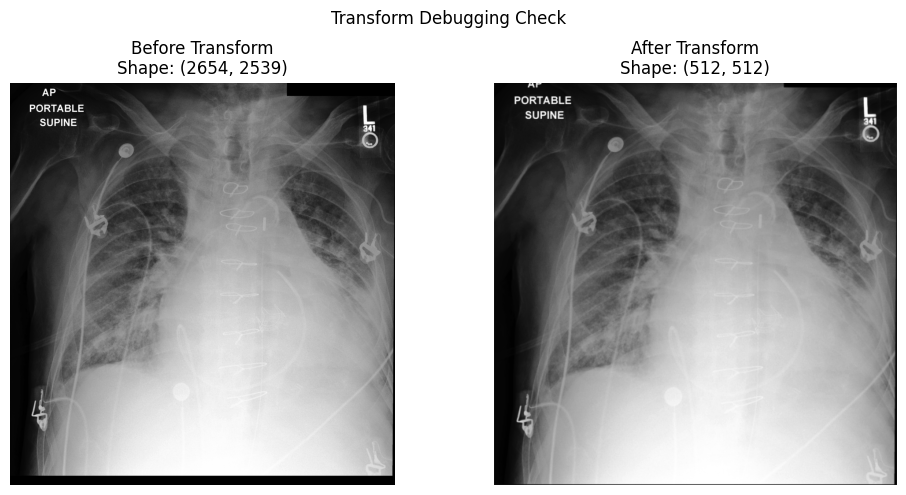

In [ ]:
import os
import torch
import skimage.io
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torchvision.transforms as transforms
import torchxrayvision as xrv

seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device)
seg_model.eval()

seg_transform = transforms.Compose([
    xrv.datasets.XRayCenterCrop(), # 기존처럼 CenterCrop으로 정사각형 비율 맞추기
    xrv.datasets.XRayResizer(512)  # 모델 규격에 맞게 512x512로 리사이징
])

anchor = 10 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :] # [1, H, W]
    
    # 1. Transform 적용 전의 원본 비율/크기 확인용 변수 저장
    img_before_transform = img[0].copy() 

    # 2. Transform 적용
    img_transformed = seg_transform(img)

    # 3. Transform 전/후 비교 출력
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_before_transform, cmap='gray')
    plt.title(f"Before Transform\nShape: {img_before_transform.shape}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # img_transformed는 (1, H, W) 형태이므로 [0]으로 2D 배열로 만듦
    plt.imshow(img_transformed[0], cmap='gray') 
    plt.title(f"After Transform\nShape: {img_transformed[0].shape}")
    plt.axis('off')
    
    plt.suptitle("Transform Debugging Check")
    plt.tight_layout()
    plt.show()

이미지: icu_cxr/mimic-cxr-jpg/2.1.0/files/p10/p10671739/s50762692/0f40ae81-c98bf6c8-517a41c6-9512149b-15771d94.jpg
--- Study ID: 50762692.0 ---
값이 1.0인 컬럼들:
['No Finding', 'Support Devices']
------------------------------


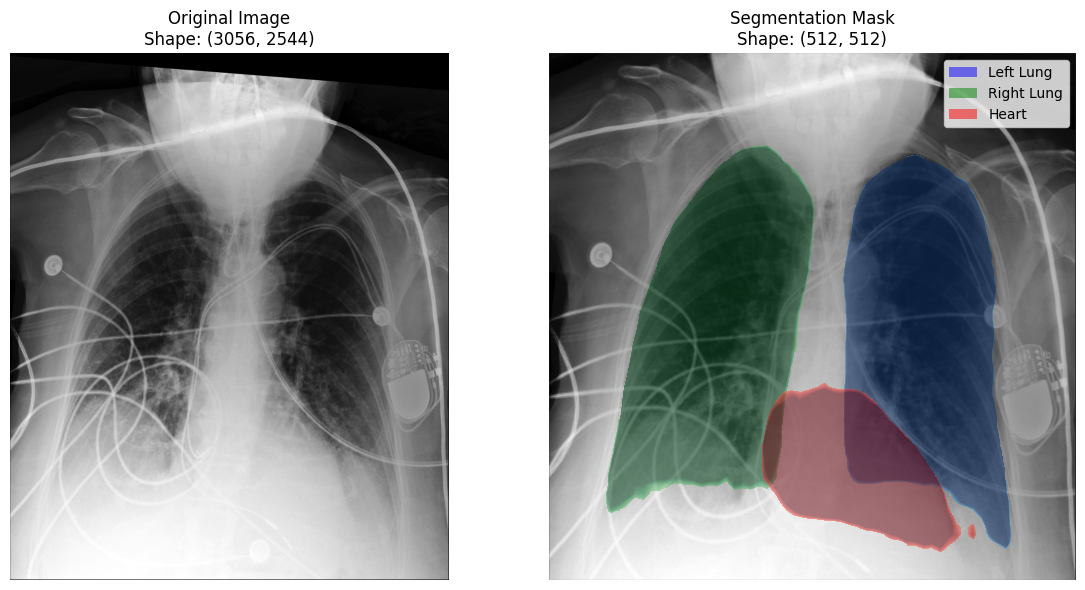

In [28]:
# --- 모델 로드 ---
seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device)
seg_model.eval()

anchor = 3000 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :] # [1, H, W]
    
    img_transformed = seg_transform(img)

    img_tensor = torch.from_numpy(img_transformed).unsqueeze(0).to(device) # [1, 1, H, W]

    # --- 추론 ---
    with torch.no_grad():
        outputs = seg_model(img_tensor) # [1, 14, 512, 512]
        masks = outputs[0].cpu().numpy()

    # 타겟 인덱스 추출 (4: Left Lung, 5: Right Lung, 8: Heart)
    left_lung_mask = masks[4]  
    right_lung_mask = masks[5] 
    heart_mask = masks[8]      

    print(f"이미지: {img_path}")
    study_id = img_path.split("/")[-2][1:]
    
    # 기존 라벨 확인 (생략 없이 그대로 유지)
    subject_df = label_csv[label_csv['study_id'] == int(study_id)]
    for index, row in subject_df.iterrows():
        positive_labels = row[row == 1.0]
        if not positive_labels.empty:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼들:")
            print(positive_labels.index.tolist())
        else:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼이 없습니다.")
        print("-" * 30)
                                
    # --- 시각화 ---
    plt.figure(figsize=(12, 6))
    
    # 1. 원본 이미지
    plt.subplot(1, 2, 1)
    orig_img = skimage.io.imread(img_path)
    plt.imshow(orig_img, cmap='gray')
    plt.title(f"Original Image\nShape: {orig_img.shape}")
    plt.axis('off')

    # 2. 세그멘테이션 마스크 오버레이 (512x512 기준)
    plt.subplot(1, 2, 2)
    # 배경 이미지도 512x512로 리사이즈된 텐서에서 가져옵니다
    bg_img_512 = img_tensor[0, 0].cpu().numpy() 
    plt.imshow(bg_img_512, cmap='gray')
    
    threshold = 0.5 
    # 마스크 오버레이 (투명도 alpha 적용)
    plt.imshow(np.ma.masked_where(left_lung_mask < threshold, left_lung_mask), cmap='Blues', alpha=0.5, vmin=0, vmax=1)
    plt.imshow(np.ma.masked_where(right_lung_mask < threshold, right_lung_mask), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
    plt.imshow(np.ma.masked_where(heart_mask < threshold, heart_mask), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    
    legend_elements = [
        Patch(facecolor='blue', alpha=0.5, label='Left Lung'),
        Patch(facecolor='green', alpha=0.5, label='Right Lung'),
        Patch(facecolor='red', alpha=0.5, label='Heart')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(f'Segmentation Mask\nShape: {bg_img_512.shape}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

### Top 5 prediction

이미지: icu_cxr/mimic-cxr-jpg/2.1.0/files/p10/p10135376/s55191825/3e866bef-c0a9555c-9665a701-75c360dd-a961f9f1.jpg
--- Study ID: 55191825.0 ---
값이 1.0인 컬럼들:
['Edema', 'Pleural Effusion', 'Support Devices']
------------------------------
Effusion: 0.9634
Lung Opacity: 0.9383
Consolidation: 0.8740
Atelectasis: 0.8688
Enlarged Cardiomediastinum: 0.8325
---------------------------------------------------------------------------------------------------------------


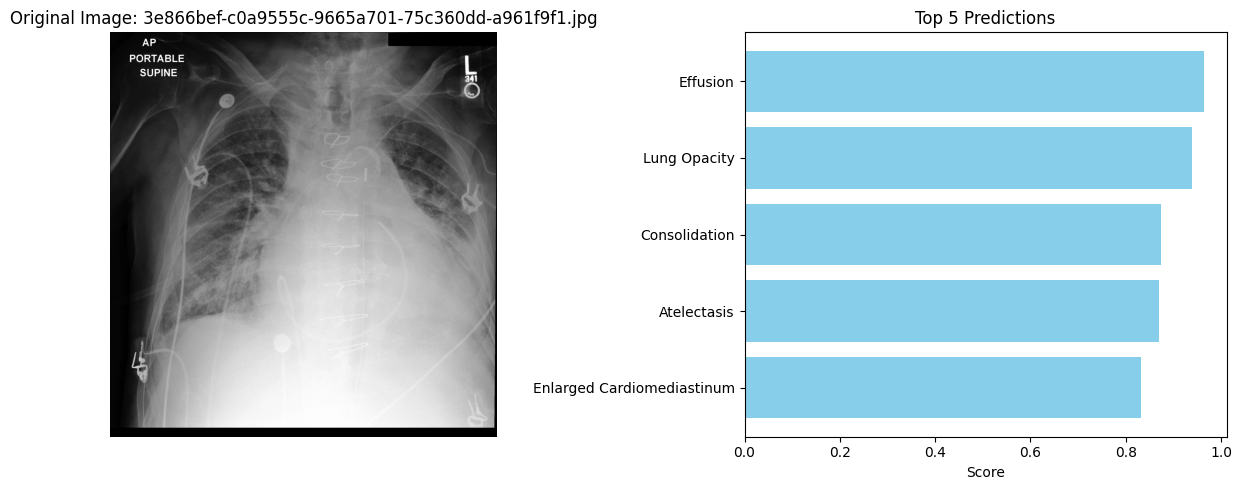

In [6]:
model = xrv.models.DenseNet(weights="densenet121-res224-mimic_ch")
model = xrv.models.DenseNet(weights="all")

transform = torchvision.transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])

model.eval()

model.to(device)

anchor = 10 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :]
    img = transform(img) 

    with torch.no_grad():
        img = torch.from_numpy(img).unsqueeze(0).to(device)
        outputs = model(img)
        # predictions = dict(zip(model.pathologies, outputs[0].cpu().numpy()))

        all_preds = zip(model.pathologies, outputs[0].cpu().numpy())
        predictions = {k: v for k, v in all_preds if k != ''}

    print(f"이미지: {img_path}")
    study_id = img_path.split("/")[-2][1:]
    subject_df = label_csv[label_csv['study_id'] == int(study_id)]
    for index, row in subject_df.iterrows():
        positive_labels = row[row == 1.0]

        if not positive_labels.empty:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼들:")
            print(positive_labels.index.tolist())
        else:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼이 없습니다.")
        print("-" * 30)
                                
    top5_predictions = sorted(predictions.items(), key=lambda item: item[1], reverse=True)[:5]
    for pathology, score in top5_predictions:
        print(f"{pathology}: {score:.4f}")
    print("-" * (len(img_path) + 5))

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(skimage.io.imread(img_path), cmap='gray')
    plt.title(f"Original Image: {os.path.basename(img_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    top_pathologies = [item[0] for item in top5_predictions]
    top_scores = [item[1] for item in top5_predictions]
    plt.barh(top_pathologies, top_scores, color='skyblue')
    plt.xlabel('Score')
    plt.title('Top 5 Predictions')
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    
    plt.show()
    
    if i >= num_images_to_process - 1:
        break

### XrayVision Model Classification Performance Check

In [2]:
split_csv = pd.read_csv('mimic-cxr-2.0.0-split.csv.gz', compression='gzip')

In [3]:
split_csv

,dicom_id,study_id,subject_id,split
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,50414267,10000032,train
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,50414267,10000032,train
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,53189527,10000032,train
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,53189527,10000032,train
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,53911762,10000032,train
...,...,...,...,...
377105,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,57132437,19999733,train
377106,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9,57132437,19999733,train
377107,58766883-376a15ce-3b323a28-6af950a0-16b793bd,55368167,19999987,train
377108,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,58621812,19999987,train


In [4]:
my_pathologies = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Lung Opacity']

In [5]:
# model = xrv.models.DenseNet(weights="densenet121-res224-mimic_ch")
model = xrv.models.DenseNet(weights="all")
model.to(device)

transform = torchvision.transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])

label_mapping = {
    'Atelectasis': 'Atelectasis',
    'Cardiomegaly': 'Cardiomegaly',
    'Consolidation': 'Consolidation',
    'Edema': 'Edema',
    'Effusion': 'Pleural Effusion', # 이름이 다르므로 매핑 필요
    'Pneumonia': 'Pneumonia',
    'Lung Opacity': 'Lung Opacity',
}

class XRayEvalDataset(Dataset):
    def __init__(self, image_paths, label_df, pathologies, mapping, transform=None):
        self.image_paths = image_paths
        self.label_df = label_df
        self.pathologies = pathologies
        self.mapping = mapping
        self.transform = transform

        self.label_dict = label_df.set_index('study_id').to_dict('index')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        img = skimage.io.imread(img_path)
        img = xrv.datasets.normalize(img, 255)
        if len(img.shape) > 2: 
            img = img[:, :, 0]
        img = img[None, :, :]
        
        if self.transform:
            img = self.transform(img)
            
        try:
            study_id = int(img_path.split("/")[-2][1:])
            subject_data = self.label_dict.get(study_id)
            
            label_row = []
            for p in self.pathologies:
                user_col_name = self.mapping.get(p)

                if subject_data is not None and user_col_name in subject_data:
                    value = subject_df.iloc[0][user_col_name]

                    if pd.isna(value):
                        label_row.append(-9)
                    elif value == 1.0:
                        label_row.append(1)
                    # U-zeros
                    else:
                        label_row.append(0)
                else: 
                    # 평가 제외 컬럼
                    label_row.append(-9)

        except:
            label_row = [-9] * len(self.pathologies)

        return torch.from_numpy(img), torch.tensor(label_row, dtype=torch.float32)

In [9]:
eval_dataset = XRayEvalDataset(
    image_paths=frontal_image_paths, 
    label_df=label_csv, 
    pathologies=model.pathologies,
    mapping=label_mapping,
    transform=transform
)

eval_loader = DataLoader(eval_dataset, batch_size=256, shuffle=False, num_workers=8)

In [10]:
print(len(model.pathologies))
print(model.pathologies)

18
['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']


In [12]:
all_outputs = []
all_labels = []

target_paths = frontal_image_paths[:] # 전체 이미지를 대상으로 함

model.eval()
with torch.inference_mode():
    for images, labels in tqdm(eval_loader, desc="XRV Model Processing"):
        images = images.to(device)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)

        all_outputs.append(outputs.float().cpu().numpy())
        all_labels.append(labels.numpy())

all_outputs = np.concatenate(all_outputs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("\n" + "="*50)
print(f"전체 {len(target_paths)}장에 대한 성능 분석 결과")
print("="*50)

auc_scores = []
prc_scores = []

for i, pathology in enumerate(model.pathologies):
    target_labels = all_labels[:, i]
    target_outputs = all_outputs[:, i]

    valid_mask = target_labels != -9
    filtered_labels = target_labels[valid_mask] 
    filtered_outputs = target_outputs[valid_mask]

    if len(filtered_labels) > 0 and len(np.unique(filtered_labels)) > 1:
        auc_val = roc_auc_score(filtered_labels, filtered_outputs)
        prc_val = average_precision_score(filtered_labels, filtered_outputs)

        auc_scores.append(auc_val)
        prc_scores.append(prc_val)
        print(f"{pathology:25s} | {auc_val:.4f} | {prc_val:.4f} | (samples: {len(filtered_labels)})")

    # else:
    #     print(f"{pathology:25s} | (Skip: No Valid Data)")

print("-" * 50)
print(f"{'Total Mean Score':25s} |  {np.mean(auc_scores):.4f}  |  {np.mean(prc_scores):.4f}")
print("="*50)

XRV Model Processing:   0%|          | 0/951 [00:00<?, ?it/s]


전체 243324장에 대한 성능 분석 결과
--------------------------------------------------
Total Mean Score          |  nan  |  nan


In [13]:
def plot_evaluation_curves(labels, outputs, pathologies):
    num_pathologies = len(pathologies)
    
    valid_indices = []
    for i in range(num_pathologies):
        if np.any(labels[:, i] != -9) and len(np.unique(labels[labels[:, i] != -9, i])) > 1:
            valid_indices.append(i)
    
    if not valid_indices:
        print("시각화할 수 있는 유효한 데이터가 없습니다.")
        return

    fig, axes = plt.subplots(len(valid_indices), 2, figsize=(12, 5 * len(valid_indices)))
    if len(valid_indices) == 1: axes = np.expand_dims(axes, axis=0)

    for idx, i in enumerate(valid_indices):
        pathology = pathologies[i]
        
        # 유효 데이터 필터링
        mask = labels[:, i] != -9
        y_true = labels[mask, i]
        y_score = outputs[mask, i]

        # 1. ROC Curve 
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        axes[idx, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        # axes[idx, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[idx, 0].set_title(f'ROC: {pathology}')
        axes[idx, 0].set_xlabel('False Positive Rate')
        axes[idx, 0].set_ylabel('True Positive Rate')
        axes[idx, 0].legend(loc="lower right")

        # 2. Precision-Recall Curve 
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        avg_precision = average_precision_score(y_true, y_score)
        
        axes[idx, 1].plot(recall, precision, color='blue', lw=2, label=f'PRC (AP = {avg_precision:.2f})')
        axes[idx, 1].set_title(f'PRC: {pathology}')
        axes[idx, 1].set_xlabel('Recall')
        axes[idx, 1].set_ylabel('Precision')
        axes[idx, 1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

plot_evaluation_curves(all_labels, all_outputs, model.pathologies)

시각화할 수 있는 유효한 데이터가 없습니다.


In [ ]:
path = "/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/00a00bb82539b548602c42e997818a74.pt"

try:
    img = torch.load(path)
    print("Load success!")
    print("Type:", type(img))
    if hasattr(img, "shape"):
        print("Shape:", img.shape)
except Exception as e:
    print("❌ Load failed:", type(e).__name__, str(e))

Load success!
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 224, 224])


In [70]:
filtered_img_df = pd.read_feather('/home/DAHS1/gangmin/my_research/CXR/filtered_img_df_20260316.ftr')
filtered_img_df

,stay_id,hour_slot,image_path,hash_path
0,37510196,0,files/p10/p10001884/s57156853/9fd47edd-0708720...,C:\Users\gangmin\dahs\my research\final_dfs_20...
1,37510196,24,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,C:\Users\gangmin\dahs\my research\final_dfs_20...
2,37510196,48,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
3,37510196,78,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,C:\Users\gangmin\dahs\my research\final_dfs_20...
4,37510196,96,files/p10/p10001884/s50376803/469d0d94-3dad506...,C:\Users\gangmin\dahs\my research\final_dfs_20...
...,...,...,...,...
53223,35165301,81,files/p19/p19999287/s52519175/f7e95a22-cb95805...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53224,35165301,99,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53225,32336619,8,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53226,36195440,6,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,C:\Users\gangmin\dahs\my research\final_dfs_20...


In [73]:
target_paths = filtered_img_df['image_path'].unique().tolist()

In [74]:
target_paths

['files/p10/p10001884/s57156853/9fd47edd-07087209-b901811e-3e9e5f50-f382f611.jpg',
 'files/p10/p10001884/s50712381/7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg',
 'files/p10/p10001884/s56722923/c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg',
 'files/p10/p10001884/s59305618/9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg',
 'files/p10/p10001884/s50376803/469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg',
 'files/p10/p10002428/s57506266/e325a8d1-1d6b0dca-404efabc-204c6bbd-599788f0.jpg',
 'files/p10/p10002428/s57064083/217e6a56-b4a78227-a2acc34d-3b571d4a-27b9746a.jpg',
 'files/p10/p10002428/s52460896/54c2ed5c-f4fbc20d-3bf4c783-283c3878-e9eb320d.jpg',
 'files/p10/p10002428/s59414737/d999236f-95dcb8b7-a4d20a3f-be538f50-ce13a08e.jpg',
 'files/p10/p10002428/s56597576/d98d5096-a32483d3-669ed39b-bc81eafb-5e251563.jpg',
 'files/p10/p10002428/s56836542/471418ab-0bfd6700-6bb770d0-07f7f6a3-2ce2d9c2.jpg',
 'files/p10/p10002428/s50292543/7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg',
 'fi

In [75]:
len(target_paths)

53228

In [ ]:
with open('my_subset_files.txt', 'w') as f:
    for path in target_paths:
        f.write(f"{path}\n")

print(f"총 {len(target_paths)}개의 경로가 저장되었습니다.")

총 53228개의 경로가 저장되었습니다.


In [ ]:
label_imputed_cxr = pd.read_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260126.ftr')
label_imputed_cxr

In [ ]:
label_imputed_cxr[(label_imputed_cxr['cxr_flag']==1) & (label_imputed_cxr['image_path'].isnull())]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing,label_source


In [ ]:
cxr_dataset = label_imputed_cxr.merge(filtered_img_df, how='left', on=['stay_id', 'hour_slot', 'image_path'])
cxr_dataset = cxr_dataset.drop(columns=['hadm_id', 'slot_start', 'slot_end', 'cxrtime'])
cxr_dataset = cxr_dataset.sort_values(['stay_id', 'hour_slot'])
cxr_5days_dataset = cxr_dataset[cxr_dataset['hour_slot'] <= 119].reset_index(drop=True)
cxr_5days_dataset = cxr_5days_dataset.drop(columns=['edema_pathophysiology', 'label_source', 'was_missing', 'image_path'])
cxr_5days_dataset['cxr_flag'] = cxr_5days_dataset['hash_path'].notna().astype(int) # New

In [ ]:
cxr_5days_dataset['hash_path'] = cxr_5days_dataset['hash_path'].apply(
    lambda x: PureWindowsPath(x).name if isinstance(x, str) else None
)

In [ ]:
print(cxr_5days_dataset['hash_path'][4])
print(cxr_5days_dataset['hash_path'][30])

997317ba341c810ae968d6b5fefcdccf.pt
809650ae1a042763fd81a266b7e27035.pt


In [ ]:
test = cxr_5days_dataset[cxr_5days_dataset['hash_path'].notnull()]

In [ ]:
broken_files = []
total = len(test)

for i in range(total):
    hash_path = test.iloc[i].hash_path
    full_path = os.path.join("/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/", hash_path)

    try:
        _ = torch.load(full_path)
    except Exception as e:  
        broken_files.append(full_path)

print("====" * 20)
print(f"전체 파일 수: {total}")
print(f"손상된 파일 수: {len(broken_files)}")
print("====" * 20)

if len(broken_files) > 0:
    print("\n손상된 파일 목록:")
    for f in broken_files:
        print(f)

전체 파일 수: 37867
손상된 파일 수: 0


In [ ]:
cxr_5days_dataset

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [ ]:
cxr_5days_dataset.to_feather('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_20260316.ftr')

In [ ]:
import torch

path = "/home/DAHS1/gangmin/my_research/CXR/cached_images_256_0317/997317ba341c810ae968d6b5fefcdccf.pt"
data = torch.load(path)

print("dtype:", data.dtype)
print("min:", data.min().item())
print("max:", data.max().item())
print("mean:", data.mean().item())
print("std:", data.std().item())

dtype: torch.bfloat16
min: 0.0
max: 1.0
mean: 0.5
std: 0.28515625
